# Forecasting Model

<div style="display: flex; justify-content: space-between;">
 <p>Forecasting model is a tool or technique used to make predictions about future events or outcomes based on historical data and patterns. It is commonly used in various fields, such as finance, economics, weather forecasting, and sales forecasting.</p>

 <p>Imagine you want to predict the weather for the next week. You can collect past weather data, such as temperature, humidity, and wind speed, and use a forecasting model to analyze the patterns and relationships in that data. The model will then make predictions about future weather conditions based on those patterns.</p>

 <p>Similarly, in finance, a forecasting model can be used to predict stock prices or market trends based on historical stock market data, company performance, and other relevant factors.</p>

 <p>A forecasting model essentially looks for patterns, trends, and relationships in the historical data and uses them to estimate what is likely to happen in the future. It helps analysts and decision-makers make informed decisions by providing them with insights into potential future outcomes.</p>

 <p>It's important to note that forecasting models are not 100% accurate, as the future is uncertain and can be influenced by various factors. However, they can provide valuable guidance and help in making more informed predictions and decisions based on available data.</p></div>



# The Imports
<div style="display: flex; justify-content: space-between;">
<p>**yfinance** is a popular Python library that provides a convenient way to access financial data from Yahoo Finance. It allows users to retrieve and analyze historical market data, current stock prices, financial statements, and more. </p>

<p>**prophet** is an open-source forecasting library developed by Facebook's Core Data Science team. It is designed to make time series forecasting accessible and easy to implement, even for users without expertise in advanced statistical models. Prophet is built on top of the Python programming language and is widely used in various industries for forecasting demand, sales, stock prices, and other time-dependent data.</p>

<p>**sklearn** is a popular open-source machine learning library for Python. It provides a wide range of tools and algorithms for data preprocessing, feature selection, model training, model evaluation, and predictive modeling tasks. Scikit-learn is designed to be easy to use, efficient, and versatile, making it a go-to choice for many machine learning practitioners and researchers.
</p></div>

In [ ]:
!pip install yfinance


In [ ]:
!pip3 install prophet

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

Here we downloads historical stock data for the ticker symbol 'CEMEXCPO.MX' from Yahoo Finance starting from January 1, 2022, and assigns it to the variable 'data'. It then displays the first 10 rows of the downloaded data.

In [ ]:
# Define the ticker symbol
ticker = 'CEMEXCPO.MX'
# Download historical data
data = yf.download(ticker, start='2022-01-01')
data.head(10)

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-03,14.08,14.14,13.74,13.78,13.78,7684055
2022-01-04,13.84,13.90,13.67,13.70,13.70,14706553
2022-01-05,13.71,14.19,13.65,13.69,13.69,16883851
2022-01-06,13.75,13.77,13.43,13.46,13.46,18589018
2022-01-07,13.45,13.50,13.25,13.35,13.35,12445595
2022-01-10,13.29,13.35,12.92,13.06,13.06,21797270
2022-01-11,13.13,13.30,13.03,13.28,13.28,25972627
2022-01-12,13.35,13.79,13.30,13.75,13.75,19195554
2022-01-13,13.78,13.85,13.67,13.80,13.80,34079037


## Prepare the data for  Prophet

prepares the historical stock data by adding additional columns such as the moving average and an indicator to facilitate further analysis or modeling tasks using the Prophet library.

In [ ]:
#Extracting the 'Close' column from the 'data' DataFrame and storing it in a new DataFrame called 'data_close'.
data_close = data[['Close']]

#Resetting the index of the 'data_close' DataFrame to ensure a sequential index.
data_close.reset_index(inplace=True)

#Renaming the columns of the 'data_close' DataFrame to 'ds' and 'y', representing the date and the target variable (in this case, the closing price).
data_close.columns = ['ds', 'y']

#Calculating the 200-day moving average (MA) of the closing price using the 'rolling' method
#and assigning the values to a new 'MA' column in the 'data_close' DataFrame. Any missing values resulting from the rolling operation are filled with zero.
data_close.loc[:, 'MA'] = data_close['y'].rolling(window=200).mean().fillna(0)

#Adding an 'Indicator' column to the 'data_close' DataFrame, which indicates whether to "Buy" or "Sell" based on a comparison between the closing price ('y') and the moving
#average ('MA'). If the closing price is greater than the moving average, it is marked as "Buy"; otherwise, it is marked as "Sell".
data_close.loc[:, 'Indicator'] = np.where(data_close['y'] > data_close['MA'], 'Buy', 'Sell')
data_close


<ipython-input-5-86bd89b321cd>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_close.loc[:, 'MA'] = data_close['y'].rolling(window=200).mean().fillna(0)
<ipython-input-5-86bd89b321cd>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_close.loc[:, 'Indicator'] = np.where(data_close['y'] > data_close['MA'], 'Buy', 'Sell')


,ds,y,MA,Indicator
0,2022-01-03,13.78,0.00000,Buy
1,2022-01-04,13.70,0.00000,Buy
2,2022-01-05,13.69,0.00000,Buy
3,2022-01-06,13.46,0.00000,Buy
4,2022-01-07,13.35,0.00000,Buy
...,...,...,...,...
376,2023-07-03,12.17,9.39790,Buy
377,2023-07-04,12.07,9.41965,Buy
378,2023-07-05,11.89,9.44130,Buy
379,2023-07-06,11.35,9.46175,Buy


This function defines a custom scoring function named score_func. The function takes two input parameters: y_true and y_pred, representing the true values and predicted values, respectively.

In [ ]:
# Define custom scoring function
def score_func(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

The TimeSeriesSplit object in this code snippet provides a specialized splitting strategy for time series data. It divides the data into consecutive and non-overlapping folds, preserving the temporal order of the observations. Each fold represents a distinct training and testing set, where the training set consists of all the observations before the test set.

In this case, the TimeSeriesSplit object is initialized with n_splits=5, indicating that the time series data will be divided into 5 folds or splits. This means that the cross-validation process will be repeated 5 times, with each split serving as a separate training and testing set. This is useful for assessing the performance of a time series model on different time periods and capturing potential changes or patterns over time.

In [ ]:
# Initialize the TimeSeriesSplit object
tscv = TimeSeriesSplit(n_splits=5)
# Initialize an empty list to store the scores
scores = []
tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

### Iterate through the splits of the data

By iterating through the cross-validation splits, fitting the model on the training data, making predictions on the test data, and calculating the score for each split, this code enables the evaluation of the Prophet model's performance across different time periods.

After executing this code, the scores list will contain the scores for each split, which can be further analyzed or averaged to assess the overall performance of the Prophet model in the time series forecasting task

In [ ]:
for train_index, test_index in tscv.split(data_close):
    # Get the training and testing data for this split
    train_data = data_close.iloc[train_index]
    test_data = data_close.iloc[test_index]
    # Fit the model on the training data
    m = Prophet(yearly_seasonality=True)
    m.fit(train_data)
    # Make predictions on the test data
    future = m.make_future_dataframe(periods=365 * 5)
    forecast = m.predict(future)
    test_predictions = forecast.iloc[-len(test_data):][['yhat']]
    # Calculate the score for this split
    score = score_func(test_data[['y']], test_predictions)
    # Append the score to the scores list
    scores.append(score)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdx5tno7j/9wwh52ou.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdx5tno7j/b2vyc2v4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80678', 'data', 'file=/tmp/tmpdx5tno7j/9wwh52ou.json', 'init=/tmp/tmpdx5tno7j/b2vyc2v4.json', 'output', 'file=/tmp/tmpdx5tno7j/prophet_modell_se3m3e/prophet_model-20230710060500.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:05:00 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpd

In [ ]:
# Calculate the mean score
mean_score = sum(scores) / len(scores)
print('Score:' + str(mean_score))

Score:92.03732793126885


In [ ]:
# Fit the model with all the data
m = Prophet(yearly_seasonality=True)
m.fit(data_close)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdx5tno7j/m7rd34zu.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdx5tno7j/cczuy3mk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91349', 'data', 'file=/tmp/tmpdx5tno7j/m7rd34zu.json', 'init=/tmp/tmpdx5tno7j/cczuy3mk.json', 'output', 'file=/tmp/tmpdx5tno7j/prophet_modelldu6hfkc/prophet_model-20230710060510.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:05:10 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:05:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


### Create a dataframe to hold predictions

In [ ]:
future = m.make_future_dataframe(periods=365 * 5)
forecast = m.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-01-03,12.829240,12.638869,13.624782,12.829240,12.829240,0.307651,0.307651,0.307651,-0.221849,-0.221849,-0.221849,0.529500,0.529500,0.529500,0.0,0.0,0.0,13.136891
1,2022-01-04,12.801794,12.751603,13.693938,12.801794,12.801794,0.403097,0.403097,0.403097,-0.173618,-0.173618,-0.173618,0.576715,0.576715,0.576715,0.0,0.0,0.0,13.204891
2,2022-01-05,12.774347,12.751989,13.735340,12.774347,12.774347,0.472089,0.472089,0.472089,-0.150647,-0.150647,-0.150647,0.622736,0.622736,0.622736,0.0,0.0,0.0,13.246436
3,2022-01-06,12.746901,12.731603,13.665935,12.746901,12.746901,0.482605,0.482605,0.482605,-0.184448,-0.184448,-0.184448,0.667053,0.667053,0.667053,0.0,0.0,0.0,13.229506
4,2022-01-07,12.719455,12.786191,13.728205,12.719455,12.719455,0.521734,0.521734,0.521734,-0.187484,-0.187484,-0.187484,0.709218,0.709218,0.709218,0.0,0.0,0.0,13.241189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2201,2028-07-01,60.594280,21.382011,97.534500,21.308143,97.885486,-0.277833,-0.277833,-0.277833,0.459023,0.459023,0.459023,-0.736855,-0.736855,-0.736855,0.0,0.0,0.0,60.316448
2202,2028-07-02,60.620337,21.504664,97.258839,21.308153,97.952298,-0.264557,-0.264557,-0.264557,0.459023,0.459023,0.459023,-0.723580,-0.723580,-0.723580,0.0,0.0,0.0,60.355780
2203,2028-07-03,60.646394,20.315814,96.964123,21.308163,98.018085,-0.930248,-0.930248,-0.930248,-0.221849,-0.221849,-0.221849,-0.708400,-0.708400,-0.708400,0.0,0.0,0.0,59.716146
2204,2028-07-04,60.672451,20.332544,97.224330,21.308173,98.076286,-0.864982,-0.864982,-0.864982,-0.173618,-0.173618,-0.173618,-0.691364,-0.691364,-0.691364,0.0,0.0,0.0,59.807469


Cross Validation Score :  92.03732793126885


<Figure size 1500x800 with 0 Axes>

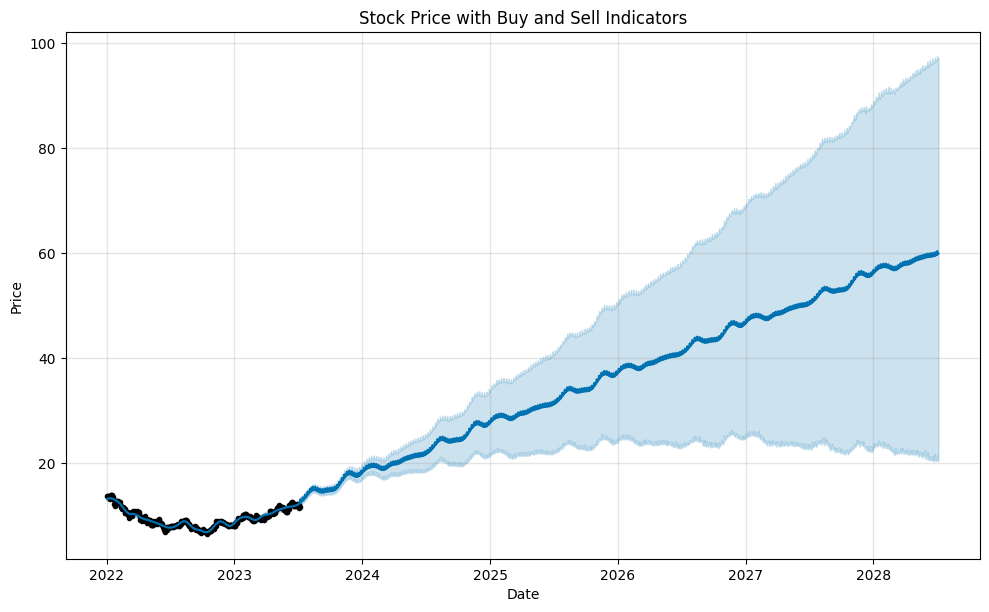

In [ ]:
# Plot the forecast
plt.figure(figsize=(15, 8))
fig1 = m.plot(forecast)
# Add labels and a title to the graph
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Price with Buy and Sell Indicators')
# Add gridlines to the graph
plt.grid(True)
# Print the mean score
print("Cross Validation Score : ", mean_score)
# Show the plot
plt.show()